In [41]:
import numpy as np
import pandas as pd
from  sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler


In [42]:
from sklearn.externals._packaging.version import parse
df=pd.read_csv('/content/TCS.csv',parse_dates=True,index_col='Date ',date_format='dd-mm-yyyy')
df.head()


,OPEN
Date,
05-Jun-24,3716.0
06-Jun-24,3781.0
07-Jun-24,3837.3
10-Jun-24,3895.0
11-Jun-24,3845.0


In [43]:
scaler=MinMaxScaler(feature_range=(0,1))
scaled_data=scaler.fit_transform(df)
scaled_data

array([[0.41734417],
       [0.46138211],
       [0.49952575],
       [0.53861789],
       [0.50474255],
       [0.52466125],
       [0.51273713],
       [0.53455285],
       [0.49190379],
       [0.4929878 ],
       [0.47154472],
       [0.49254743],
       [0.48018293],
       [0.48577236],
       [0.50440379],
       [0.49525745],
       [0.55406504],
       [0.53116531],
       [0.60542005],
       [0.62330623],
       [0.60965447],
       [0.61653117],
       [0.62466125],
       [0.5995935 ],
       [0.59871274],
       [0.56300813],
       [0.59620596],
       [0.76944444],
       [0.72628726],
       [0.71815718],
       [0.82479675],
       [0.81297425],
       [0.80149051],
       [0.8045393 ],
       [0.8096206 ],
       [0.84688347],
       [0.89092141],
       [0.874729  ],
       [0.84688347],
       [0.8803523 ],
       [0.85704607],
       [0.77168022],
       [0.72557588],
       [0.76422764],
       [0.73238482],
       [0.75677507],
       [0.76558266],
       [0.754

In [44]:
data = df["OPEN "].values.reshape(-1,1)

In [45]:
df.columns = df.columns.str.upper()
data = df["OPEN "].values.reshape(-1,1)

In [46]:
scaler = MinMaxScaler(feature_range= (0,1))
scaler_data = scaler.fit_transform(data)

In [47]:
train_data = scaler_data[:227]
test_data = scaler_data[227:]

Arrange train and test data as timestamp .in our case 5 timestamps

In [48]:
ts = 5
x_train=[]
y_train=[]
x_test=[]
y_test=[]
for i in range(ts,len(train_data)):
    x_train.append(train_data[i-ts:i])
    y_train.append(train_data[i])
for i in range(ts,len(test_data)):
    x_test.append(test_data[i-ts:i])
    y_test.append(test_data[i])
x_train = np.array(x_train)
y_train = np.array(y_train)
x_test = np.array(x_test)
y_test = np.array(y_test)
print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

(222, 5, 1) (222, 1) (16, 5, 1) (16, 1)


In [49]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,LSTM,Input

In [50]:
model = Sequential()
model.add(Input(shape=(5,1)))
#input_shape is (time_stamps.features)
model.add(LSTM(units=3))
model.add(Dense(1))  # wighted operation is performing
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 3)              │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64 (256.00 B)

 Trainable params: 64 (256.00 B)

 Non-trainable params: 0 (0.00 B)

In [51]:
from tensorflow.keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.001),loss='mean_squared_error')
model.fit(x_train,y_train,epochs=25,batch_size=32,validation_data=(x_test,y_test))

Epoch 1/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 1.0036 - val_loss: 0.1544
Epoch 2/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.8953 - val_loss: 0.1239
Epoch 3/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.7993 - val_loss: 0.0964
Epoch 4/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.7739 - val_loss: 0.0720
Epoch 5/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.6481 - val_loss: 0.0510
Epoch 6/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.5619 - val_loss: 0.0335
Epoch 7/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.5226 - val_loss: 0.0195
Epoch 8/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.4263 - val_loss: 0.0094
Epoch 9/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.3741 - val_loss: 0.0033
Epoch 10/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3111 - val_loss: 0.0012
Epoch 11/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2451 - val_loss: 0.0029
Epoch 12/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1884 - val_loss: 0.0082
E

In [52]:
import matplotlib.pyplot as plt


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


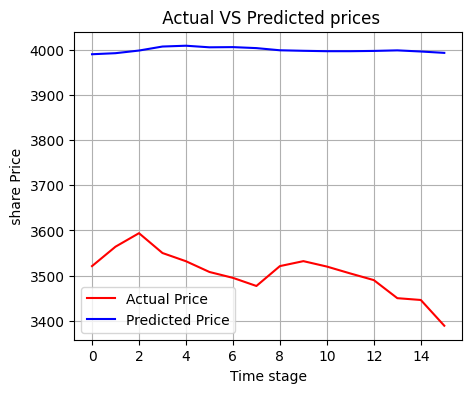

In [54]:
y_pred = model.predict(x_test)

actual_prices = scaler.inverse_transform(y_test)
predicted_prices = scaler.inverse_transform(y_pred)
plt.figure(figsize=(5,4))
plt.plot(actual_prices,color='red',label='Actual Price')
plt.plot(predicted_prices,color='blue',label='Predicted Price')
plt.title(' Actual VS Predicted prices')
plt.xlabel('Time stage')
plt.ylabel(' share Price ')
plt.legend()
plt.grid(True)
plt.show()
